In [101]:
# Importing required libraries for regression model training
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [102]:
# Loading the dataset
df = pd.read_csv(r"D:\Three-capstone-projects\Employee_Salary_Prediction\dataset\salary_prediction_dataset.csv")

The dataset is about job salary based on experience and acadamic qualification, professional certificates etc

In [103]:
# Inspecting the dataset
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [104]:
df.sample(10)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
112371,Business Analyst,20,Diploma,11,Media,Large,Singapore,Hybrid,4,151582
199212,Product Manager,4,Bachelor,7,Manufacturing,Enterprise,Sweden,No,4,151587
158234,Frontend Developer,12,Diploma,10,Government,Small,Remote,Yes,5,119348
84203,Data Scientist,8,Diploma,18,Consulting,Startup,Netherlands,No,3,123912
206928,Data Analyst,14,Diploma,18,Healthcare,Large,Australia,Yes,0,130427
219746,Data Scientist,13,PhD,3,Healthcare,Medium,UK,No,5,183647
214044,Frontend Developer,9,PhD,2,Education,Small,Netherlands,No,4,118475
164062,Software Engineer,6,Master,16,Technology,Medium,Canada,Yes,2,169124
172904,Software Engineer,0,High School,13,Telecom,Small,UK,Hybrid,0,93961
42018,Machine Learning Engineer,8,High School,11,Consulting,Enterprise,Germany,Yes,4,193316


In [105]:
#Check number of rows and comlumns
df.shape

(250000, 10)

In [106]:
# getting information of the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 30.7 MB


Information reveals that all columns are numerical and have no missing values

In [107]:
# Genrating summary statistics
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [108]:
# check for any misiing values
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [109]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [84]:
# check the corelation of the numerical values
df.corr(numeric_only=True)

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000149,-0.000198,0.437627
skills_count,0.000149,1.000000,-0.002230,0.127300
certifications,-0.000198,-0.002230,1.000000,0.073819
salary,0.437627,0.127300,0.073819,1.000000


Eperience has positive correlation with salary

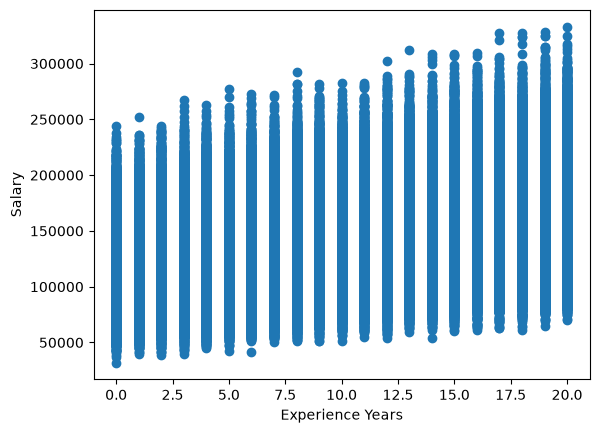

In [110]:
# scatter plot for experience years and salary
plt.scatter(df['experience_years'], df['salary'])
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.show()

<Axes: ylabel='experience_years'>

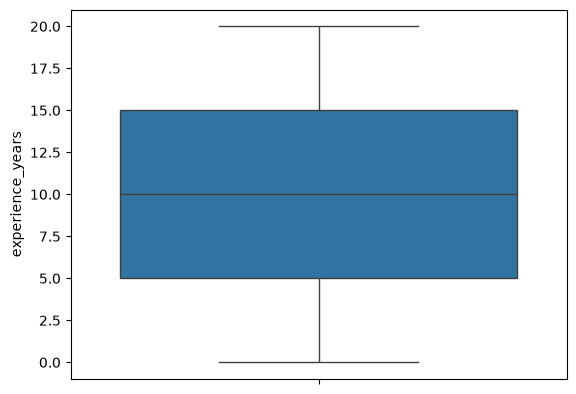

In [111]:
# checking outlier in experience years
sns.boxplot(df['experience_years'])

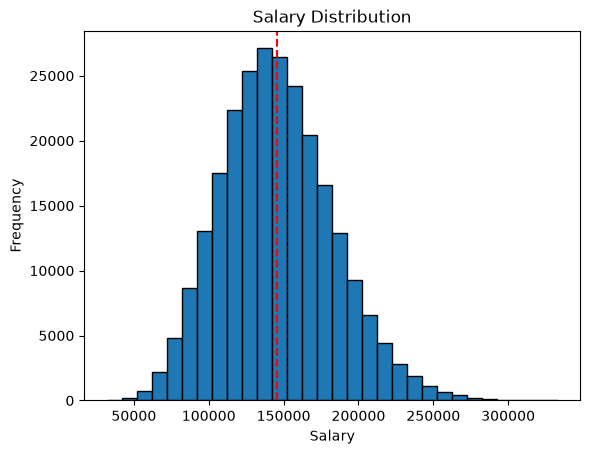

In [112]:
# To see the slary distribution use histo-gram plotting
plt.hist(df["salary"],bins=30,edgecolor="black")
plt.axvline(df["salary"].mean(), color="red", linestyle="--", label="Mean")
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

In [116]:
# Split the data into features and target variables
X = df.drop('salary', axis=1)
y = df['salary']

In [118]:
# Encoding for the variables
X = pd.get_dummies(X, drop_first=True)
print(X.dtypes)

experience_years                       int64
skills_count                           int64
certifications                         int64
job_title_Backend Developer             bool
job_title_Business Analyst              bool
job_title_Cloud Engineer                bool
job_title_Cybersecurity Analyst         bool
job_title_Data Analyst                  bool
job_title_Data Scientist                bool
job_title_DevOps Engineer               bool
job_title_Frontend Developer            bool
job_title_Machine Learning Engineer     bool
job_title_Product Manager               bool
job_title_Software Engineer             bool
education_level_Diploma                 bool
education_level_High School             bool
education_level_Master                  bool
education_level_PhD                     bool
industry_Education                      bool
industry_Finance                        bool
industry_Government                     bool
industry_Healthcare                     bool
industry_M

In [119]:
X.head()

,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [120]:
train_columns = X.columns
joblib.dump(train_columns, r"D:\Three-capstone-projects\Employee_Salary_Prediction\models\train_columns.joblib")

['D:\\Three-capstone-projects\\Employee_Salary_Prediction\\models\\train_columns.joblib']

In [92]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [94]:
# Here two models are selected and experiement to get good performance out of them
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

In [95]:
import time
results = [] # to store models results
trained_model = {} # for models
for name, model in models.items():
    print(f"\nTraining model : {name}")
    start_time = time.time()
    # Train the current model 
    model.fit(X_train, y_train)
    # Make predictions
    y_pred = model.predict(X_test)
    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Calculate training time
    training_time = time.time() - start_time

    # Store trained model
    trained_model[name] = model

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2,
        "Training Time (sec)": training_time
    })

    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R² Score : {r2:.4f}")




Training model : Random Forest
MAE : 5740.69
MSE : 55368716.65
RMSE : 7441.02
R² Score : 0.9602

Training model : HistGradient Boosting
MAE : 4199.52
MSE : 27710022.02
RMSE : 5264.03
R² Score : 0.9801


In [96]:
# Initialize variables to store the best model
best_model_name = None
best_model = None
best_r2 = float("-inf")

# Loop through each result
for result in results:

    # Check if current model has a better R² score
    if result["R² Score"] > best_r2:

        # Update the best R² score
        best_r2 = result["R² Score"]

        # Store the name of the best model
        best_model_name = result["Model"]

        # Retrieve the trained model
        best_model = trained_model[best_model_name]

# Display the selected model
print("Selected Model:", best_model_name)
print("Best R² Score:", best_r2)

Selected Model: HistGradient Boosting
Best R² Score: 0.9800627764134231


The HistGradientBoosting Regressor achieved superior predictive performance, with a lower MAE and RMSE and a higher R² score compared with Random Forest. It also produced a significantly smaller serialized model, making it more efficient for deployment. Therefore, HistGradientBoosting Regressor was selected as the final model.

In [97]:
# Making prediction from best model
y_pred = best_model.predict(X_test)

In [98]:
# see the difference of actual and predicted values with random check 
df_compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_compare.sample(5)

,Actual,Predicted
159188,165630,167815.551967
221497,155618,144295.873286
172170,184317,194854.552657
110387,205885,201934.208192
219843,94809,98915.961489


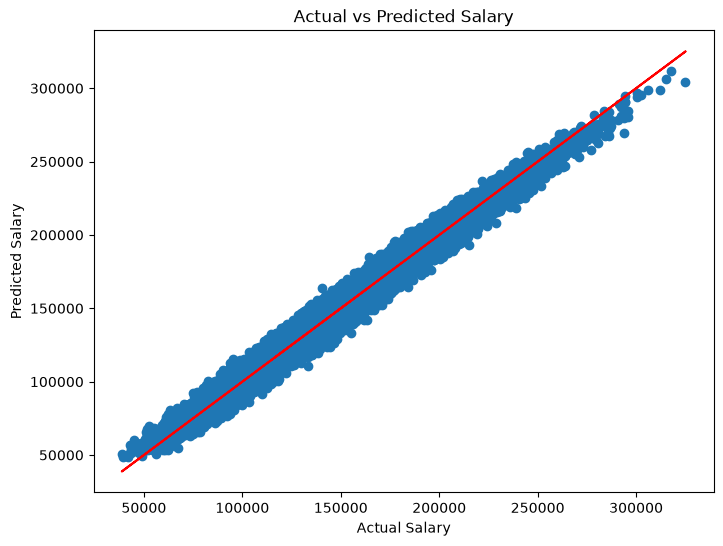

In [99]:
# draw the linear relation using scatter plot and draw red line
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='red')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()

In [100]:
# Dumping the model using joblib
joblib.dump(best_model, r'D:\Three-capstone-projects\Employee_Salary_Prediction\models\salary_prediction_model.joblib') 

['D:\\Three-capstone-projects\\Employee_Salary_Prediction\\models\\salary_prediction_model.joblib']